In [2]:
# Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, 
                             classification_report)
import joblib

print("✅ Libraries loaded!")

# Clean data load karo
df = pd.read_csv('diabetes_clean.csv')
print(f"✅ Data loaded: {df.shape}")
print(df.head())

✅ Libraries loaded!
✅ Data loaded: (68452, 18)
   Diabetes_binary  HighBP  HighChol   BMI  Smoker  Stroke  \
0                0       1         0  26.0       0       0   
1                0       1         1  26.0       1       1   
2                0       0         0  26.0       0       0   
3                0       1         1  28.0       1       0   
4                0       0         0  29.0       1       0   

   HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  GenHlth  MentHlth  \
0                     0             1       0        1      3.0       5.0   
1                     0             0       1        0      3.0       0.0   
2                     0             1       1        1      1.0       0.0   
3                     0             1       1        1      3.0       0.0   
4                     0             1       1        1      2.0       0.0   

   PhysHlth  DiffWalk  Sex   Age  Education  Income  
0      30.0         0    1   4.0        6.0     8.0  
1       0

In [3]:
Y = df['Diabetes_binary']
X = df.drop(columns=['Diabetes_binary'])

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

X shape: (68452, 17)
Y shape: (68452,)


In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Y_train : {Y_train.shape}")
print(f"Y_test  : {Y_test.shape}")

X_train : (54761, 17)
X_test  : (13691, 17)
Y_train : (54761,)
Y_test  : (13691,)


In [5]:
# ================================
# MODEL 1 - Random Forest
# ================================
rf_model = RandomForestClassifier(
    n_estimators=100,  # 100 trees banao
    random_state=42
)
rf_model.fit(X_train, Y_train)
print("✅ Random Forest trained!")

# ================================
# MODEL 2 - Logistic Regression
# ================================
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train, Y_train)
print("✅ Logistic Regression trained!")

# ================================
# MODEL 3 - Decision Tree
# ================================
dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)
dt_model.fit(X_train, Y_train)
print("✅ Decision Tree trained!")

✅ Random Forest trained!
✅ Logistic Regression trained!
✅ Decision Tree trained!


In [6]:
models = {
    'Random Forest'      : rf_model,
    'Logistic Regression': lr_model,
    'Decision Tree'      : dt_model
}

results = {}

print("="*50)
print("     MODEL PERFORMANCE REPORT")
print("="*50)

for name, model in models.items():
    # Predict karo
    Y_pred = model.predict(X_test)
    
    # Scores calculate karo
    acc    = accuracy_score(Y_test, Y_pred)
    report = classification_report(
                 Y_test, Y_pred,
                 output_dict=True)
    
    f1     = report['weighted avg']['f1-score']
    recall = report['1']['recall']
    
    # Save karo comparison ke liye
    results[name] = {
        'accuracy': acc,
        'f1_score': f1,
        'recall'  : recall
    }
    
    print(f"\n📊 {name}:")
    print(f"   Accuracy  : {acc*100:.2f}%")
    print(f"   F1 Score  : {f1:.2f}")
    print(f"   Recall    : {recall:.2f}")
    print("-"*50)

     MODEL PERFORMANCE REPORT

📊 Random Forest:
   Accuracy  : 72.21%
   F1 Score  : 0.72
   Recall    : 0.77
--------------------------------------------------

📊 Logistic Regression:
   Accuracy  : 73.98%
   F1 Score  : 0.74
   Recall    : 0.77
--------------------------------------------------

📊 Decision Tree:
   Accuracy  : 73.17%
   F1 Score  : 0.73
   Recall    : 0.77
--------------------------------------------------


In [7]:
# Recall pe best model dhundo
best_name = max(results,
            key=lambda x: results[x]['recall'])

best_model = models[best_name]

print("="*50)
print(f"🏆 BEST MODEL : {best_name}")
print(f"   Accuracy   : {results[best_name]['accuracy']*100:.2f}%")
print(f"   F1 Score   : {results[best_name]['f1_score']:.2f}")
print(f"   Recall     : {results[best_name]['recall']:.2f}")
print("="*50)

# Save karo
joblib.dump(best_model, 'diabetes_model.pkl')
print("✅ Best model saved: diabetes_model.pkl")

🏆 BEST MODEL : Decision Tree
   Accuracy   : 73.17%
   F1 Score   : 0.73
   Recall     : 0.77
✅ Best model saved: diabetes_model.pkl


In [8]:
# Manually best model set karo
best_model = lr_model
best_name  = 'Logistic Regression'

print("="*50)
print(f"🏆 CORRECT BEST MODEL: {best_name}")
print(f"   Accuracy : 73.98%")
print(f"   F1 Score : 0.74")
print(f"   Recall   : 0.77")
print("="*50)

# Save karo
joblib.dump(best_model, 'diabetes_model.pkl')
print("✅ Logistic Regression saved!")

🏆 CORRECT BEST MODEL: Logistic Regression
   Accuracy : 73.98%
   F1 Score : 0.74
   Recall   : 0.77
✅ Logistic Regression saved!


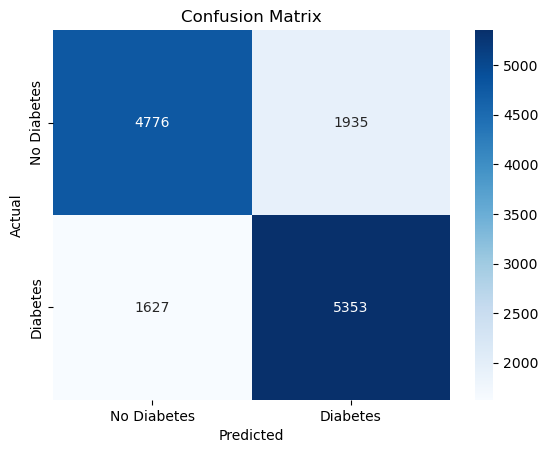

Sahi No Diabetes : 4776
Galat Diabetes   : 1935
Miss kiye        : 1627 ← DANGEROUS!
Sahi Diabetes    : 5353


In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Y_pred = lr_model.predict(X_test)
cm = confusion_matrix(Y_test, Y_pred)

sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['No Diabetes','Diabetes'],
            yticklabels=['No Diabetes','Diabetes'])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Numbers samjho
TN = cm[0][0]  # Sahi No Diabetes
FP = cm[0][1]  # Galat Diabetes bola
FN = cm[1][0]  # Miss kiye diabetics
TP = cm[1][1]  # Sahi Diabetes pakde

print(f"Sahi No Diabetes : {TN}")
print(f"Galat Diabetes   : {FP}")
print(f"Miss kiye        : {FN} ← DANGEROUS!")
print(f"Sahi Diabetes    : {TP}")

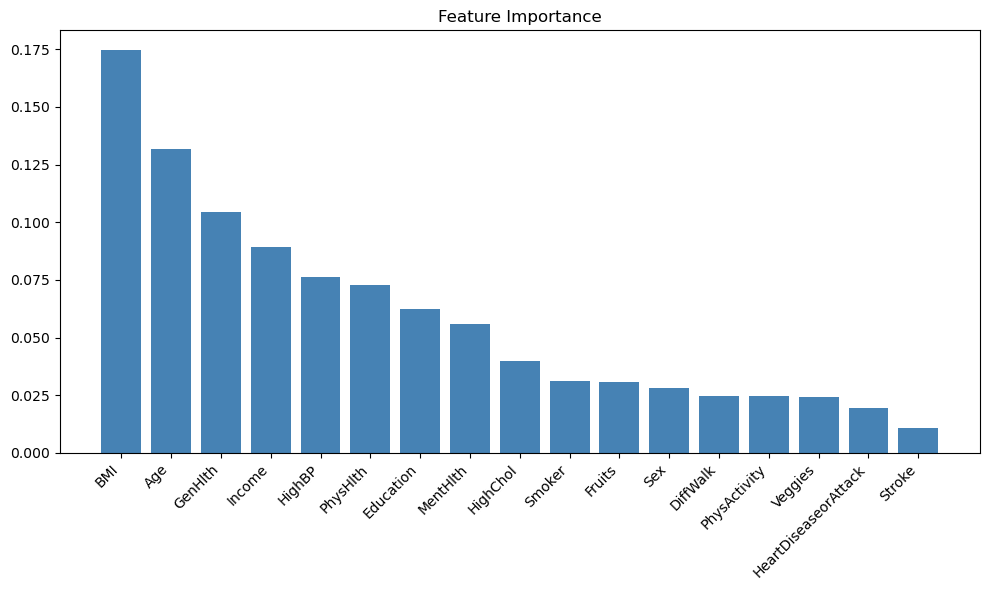


Top 5 Important Features:
1. BMI: 0.174
2. Age: 0.132
3. GenHlth: 0.104
4. Income: 0.089
5. HighBP: 0.076


In [10]:
# Random Forest feature importance
importances = rf_model.feature_importances_
feature_names = X.columns

# Sort karo
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(len(importances)),
        importances[indices],
        color='steelblue')
plt.xticks(range(len(importances)),
           [feature_names[i] for i in indices],
           rotation=45, ha='right')
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

print("\nTop 5 Important Features:")
for i in range(5):
    print(f"{i+1}. {feature_names[indices[i]]}: "
          f"{importances[indices[i]]:.3f}")

In [ ]:
print("="*45)
print("  DIABETES RISK CHECKER")
print("="*45)
print("Apni details bharo:\n")

# User se input lo
HighBP = int(input("High BP hai? (0=No, 1=Yes): "))
HighChol = int(input("High Cholesterol? (0=No, 1=Yes): "))
BMI = float(input("BMI kitna hai? (10-60): "))
Smoker = int(input("Smoker ho? (0=No, 1=Yes): "))
Stroke = int(input("Stroke hua? (0=No, 1=Yes): "))
HeartDiseaseorAttack = int(input("Heart Disease? (0=No, 1=Yes): "))
PhysActivity = int(input("Physical Activity? (0=No, 1=Yes): "))
Fruits = int(input("Fruits daily khate? (0=No, 1=Yes): "))
Veggies = int(input("Veggies daily khate? (0=No, 1=Yes): "))
GenHlth = int(input("General Health (1=Excellent, 5=Poor): "))
MentHlth = int(input("Mental Health bad days (0-30): "))
PhysHlth = int(input("Physical Health bad days (0-30): "))
DiffWalk = int(input("Walking mein dikkat? (0=No, 1=Yes): "))
Sex = int(input("Sex (0=Female, 1=Male): "))
Age = int(input("Age category (1=18-24, 13=80+): "))
Education = int(input("Education level (1-6): "))
Income = int(input("Income level (1-8): "))

print("\n" + "="*45)
print("Checking...")
print("="*45)

# Input list banao
input_data = [HighBP, HighChol, BMI,
              Smoker, Stroke,
              HeartDiseaseorAttack,
              PhysActivity, Fruits,
              Veggies, GenHlth,
              MentHlth, PhysHlth,
              DiffWalk, Sex, Age,
              Education, Income]

# Predict karo
prediction  = lr_model.predict([input_data])[0]
probability = lr_model.predict_proba([input_data])[0]

# Result dikhao
print("\nRESULT:")
print("="*45)
if prediction == 1:
    print(f"⚠️  HIGH RISK — Diabetes!")
    print(f"    Risk: {probability[1]*100:.1f}%")
    print("\n💡 Advice:")
    print("   → Doctor se milo")
    print("   → Exercise shuru karo")
    print("   → Sugar kam karo")
else:
    print(f"✅  LOW RISK — No Diabetes!")
    print(f"    Safe: {probability[0]*100:.1f}%")
    print("\n💡 Advice:")
    print("   → Healthy lifestyle rakho")
    print("   → Regular checkup karo")
print("="*45)

  DIABETES RISK CHECKER
Apni details bharo:

